In [125]:
import mplhep
mplhep.style.use('ROOT')
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import hist
import uproot

class HistFile:
    def __init__(self, fp, ana, **kwargs):
        self._file = uproot.open(fp, **kwargs)
        self._ana = ana
        self._ana_dir = self._file[self._ana]

    def keys(self):
        return [
            key.removeprefix(f'{self._ana}_').removesuffix(';1')
            for key in self._ana_dir.keys()
        ]

    def __getitem__(self, item):
        if item in self._ana_dir:
            return self._ana_dir[item]
        if item in self._file:
            return self._file[item]
        return self._ana_dir[f'{self._ana}_{item}']

In [127]:
f = HistFile('hist_track_ana_1_TEST.root', 'TrackAnalyzer')

In [128]:
f.keys()

['impact_point',
 'leadtrk_impact_point',
 'leadtrk_nhits_10_impact_point',
 'leadtrk_nhits_10_neg_charge_impact_point',
 'reco_momentum',
 'sim_momentum',
 'reco_leadtrk_momentum',
 'reco_leadtrk_momentum_all_reqs',
 'leadtrk_reco_vs_sim_momentum',
 'leadtrk_reco_vs_sim_momentum_all_reqs',
 'leadtrk_reco_vs_sim_momentum_nhits_10',
 'leadtrk_chi2',
 'leadtrk_chi2_nhits_10',
 'leadtrk_chi2_nhits_10_impact_cuts',
 'leadtrk_all_req_reduced_chi2',
 'leadtrk_reco_all_reqs_vs_Energy_Estimate_Beamspot',
 'difference_Beamspot',
 'energy_diff_vs_chi2_Beamspot']

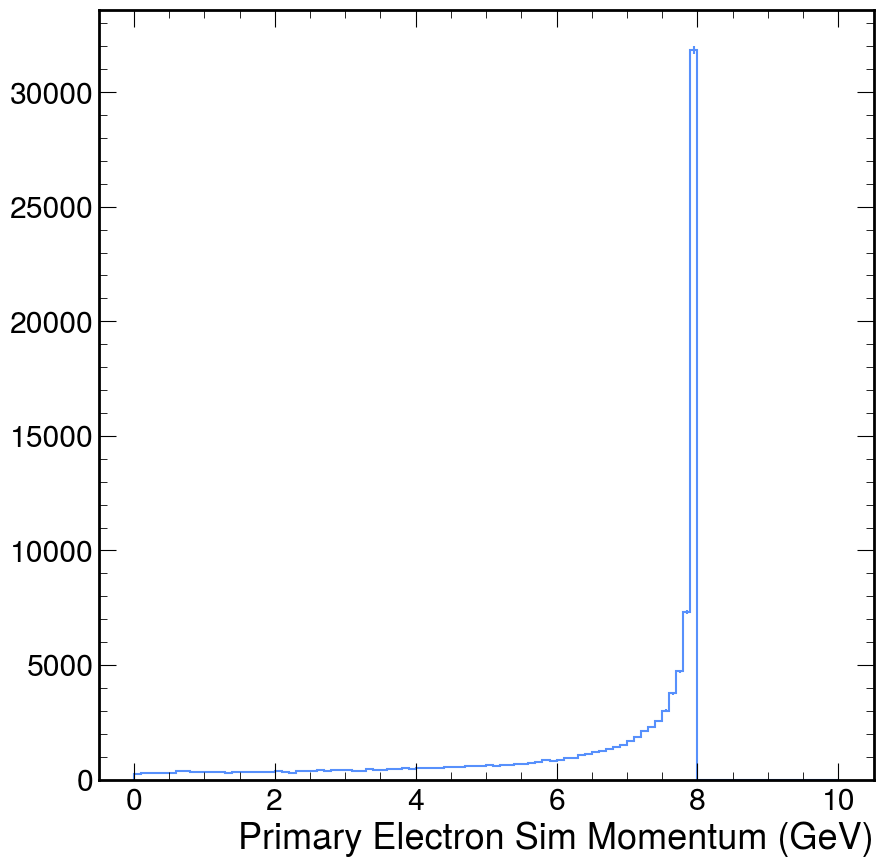

In [129]:
g = f['sim_momentum'].to_hist().plot()
#plt.savefig("reco_momentum.jpg")

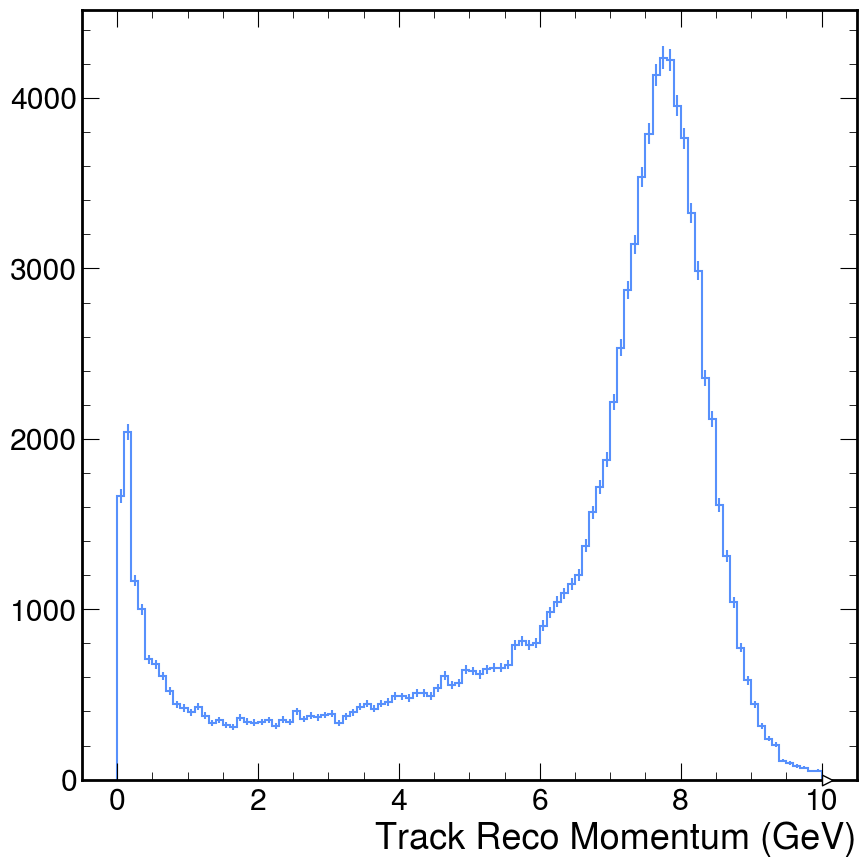

In [130]:
g = f['reco_momentum'].to_hist().plot()
#plt.savefig("reco_momentum.jpg")

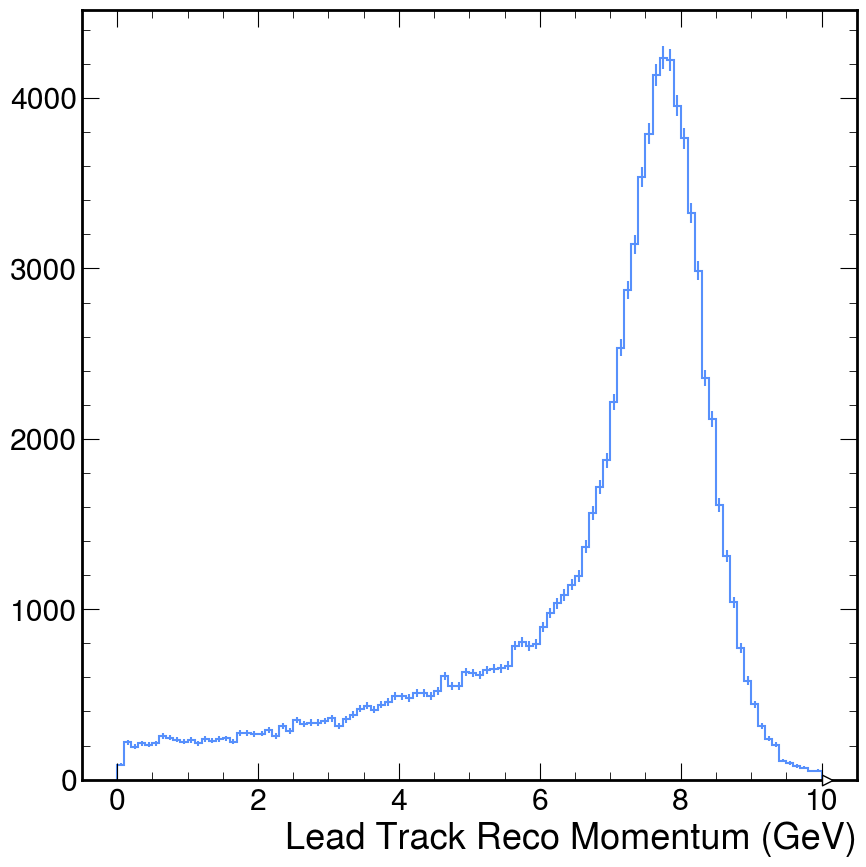

In [131]:
g = f['reco_leadtrk_momentum'].to_hist().plot()
#plt.savefig("leadtrk_reco_momentum.jpg")

Text(1, 0, 'Reco Track Momentum [GeV]')

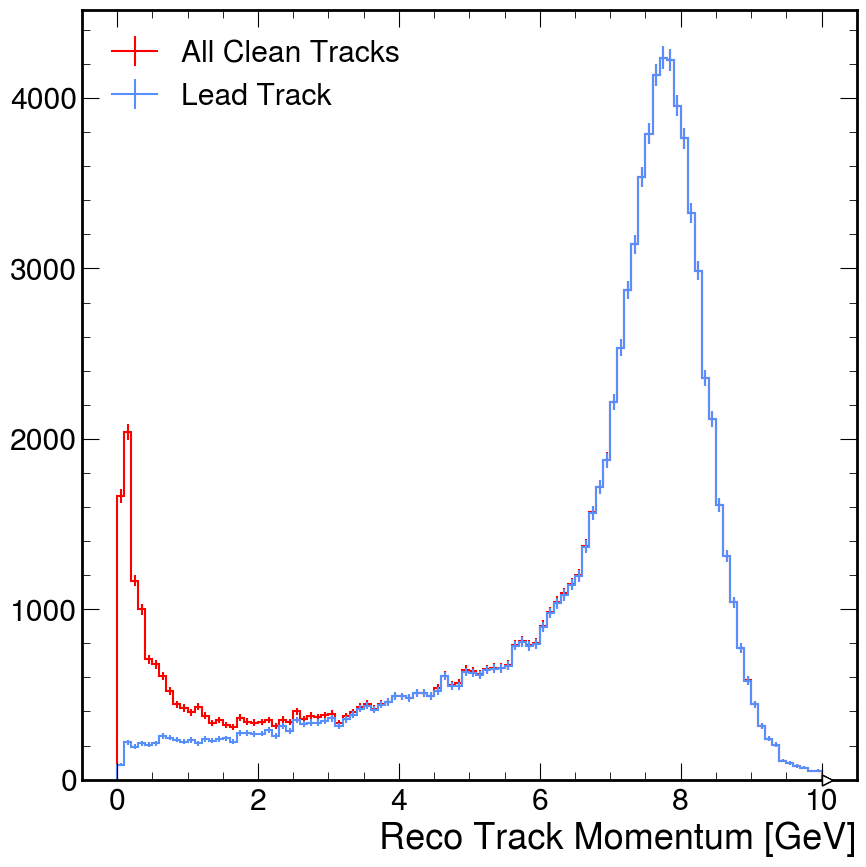

In [132]:
hh = f['reco_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "All Clean Tracks")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track")
plt.legend(loc='best')
plt.xlabel('Reco Track Momentum [GeV]')
#plt.ylim(0,5000)
#plt.yscale("log")
#plt.savefig("10M_clean_vs_leadtrk_reco_1D.jpg")

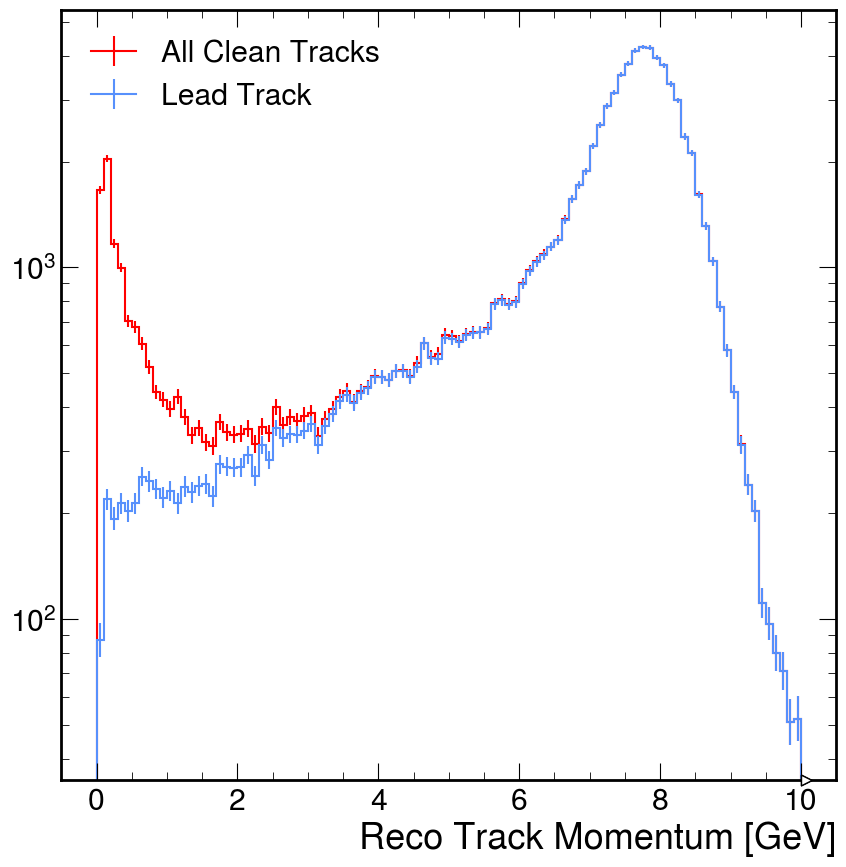

In [133]:
hh = f['reco_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "All Clean Tracks")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track")
plt.legend(loc='best')
plt.xlabel('Reco Track Momentum [GeV]')
#plt.ylim(0,5000)
plt.yscale("log")
#plt.savefig("10M_clean_vs_leadtrk_reco_1D_log.jpg")

90.0 3.5999999999999996
75.0 6.0


Text(0, 1, 'Fraction Above')

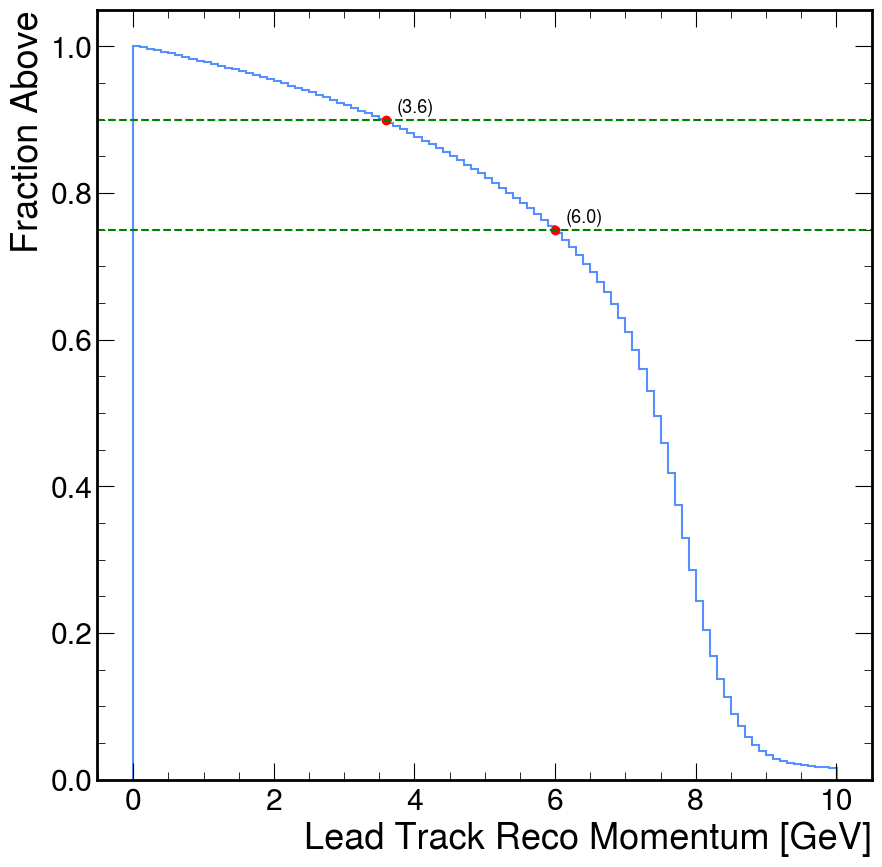

In [134]:
h = f['reco_leadtrk_momentum'].to_hist()
import numpy as np

fraction_above = np.flip(np.cumsum(np.flip(h.values(flow=True))))/np.sum(h.values(flow=True))
momentum = np.concatenate(([h.axes[0].edges[0]-0.01],h.axes[0].edges,[h.axes[0].edges[-1]+0.01]))

mplhep.histplot(fraction_above, bins = momentum)

for thresh in (0.9, 0.75):
    first_above = momentum[np.argmin(fraction_above>thresh)]
    print(100*thresh, first_above)
    #plt.annotate(f'(90%, {first_above:.2f} GeV)', (0.9,first_above), va='bottom', ha='left')
    #plt.axvline(first_above, label = " str(first_above) +, color = "r")
    plt.plot(first_above,thresh,'ro') 
    plt.text(first_above+0.15, thresh+0.01, f"({np.round(first_above,decimals=3)})", fontsize=13)
    plt.axhline(thresh, color = "g", linestyle='--')

plt.xlabel('Lead Track Reco Momentum [GeV]')
plt.ylabel('Fraction Above')
#plt.legend(loc= "best")
#plt.savefig("cumsum_plot.jpg")

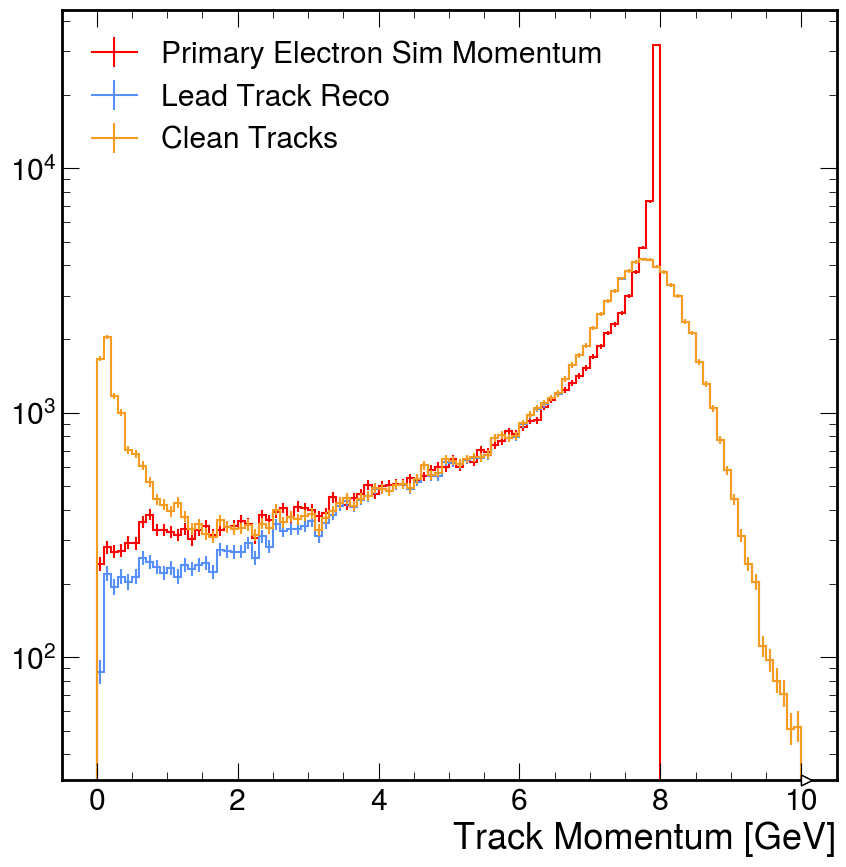

In [135]:
hh = f['sim_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Primary Electron Sim Momentum")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track Reco")
d = f['reco_momentum'].to_hist().plot(label = "Clean Tracks")
plt.legend(loc='best')
plt.xlabel('Track Momentum [GeV]')
plt.yscale("log")
#plt.savefig("10M_sim_clean_vs_lead_reco_1D-log.jpg")

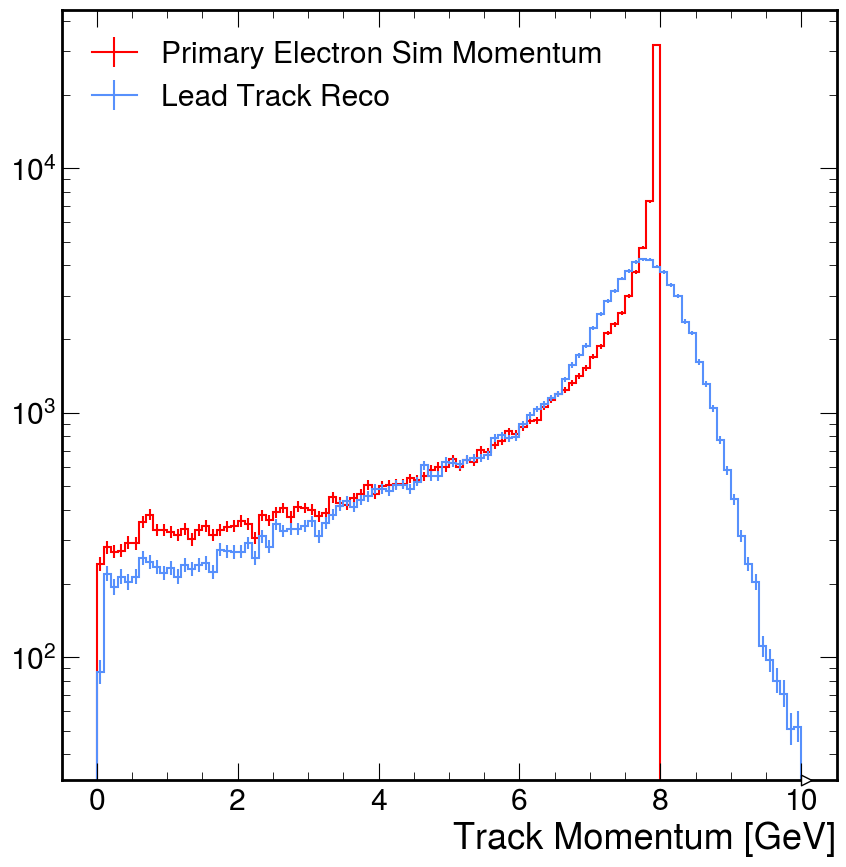

In [136]:
hh = f['sim_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Primary Electron Sim Momentum")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Lead Track Reco")
#d = f['reco_momentum'].to_hist().plot(label = "Clean Tracks")
plt.legend(loc='best')
plt.xlabel('Track Momentum [GeV]')
plt.yscale("log")
#plt.savefig("sim_clean_vs_lead_reco_1D-log-sample.jpg")

(-70.0, 70.0)

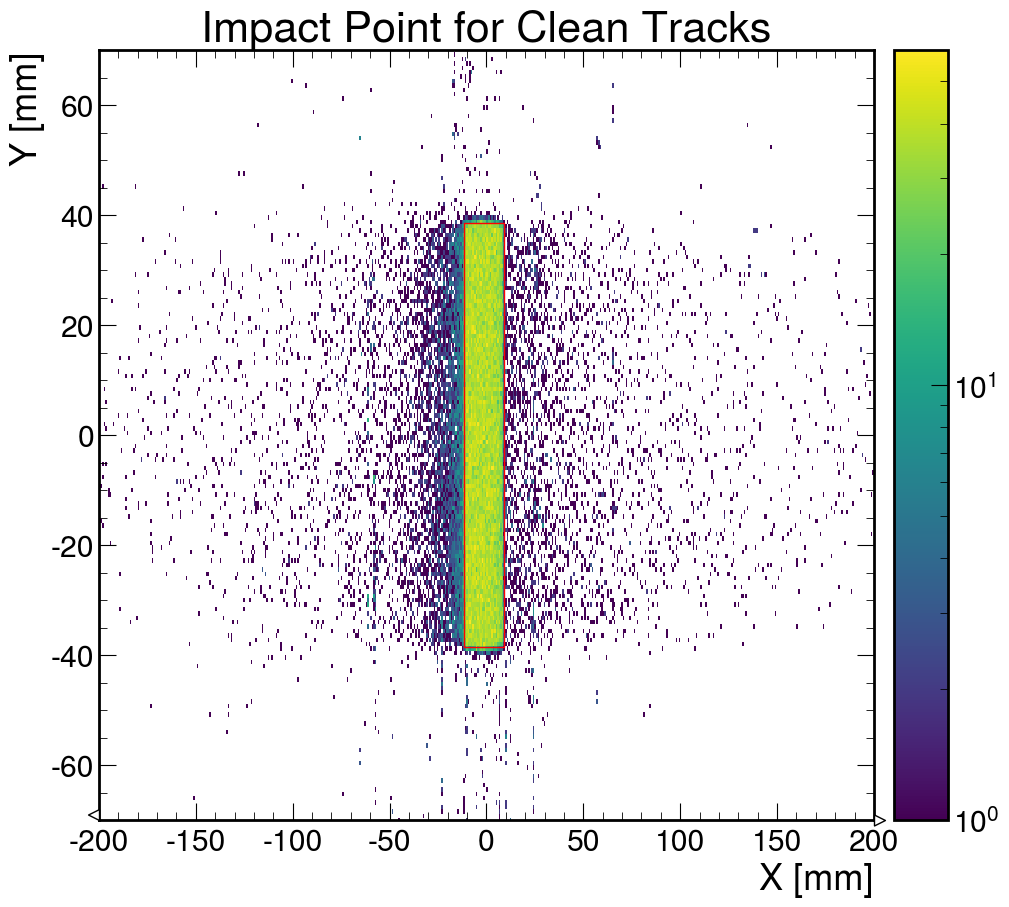

In [137]:
f['impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Clean Tracks")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.ylim(-70,70)
#plt.savefig("10M_impact_point_clean_tracks.jpg")

(-70.0, 70.0)

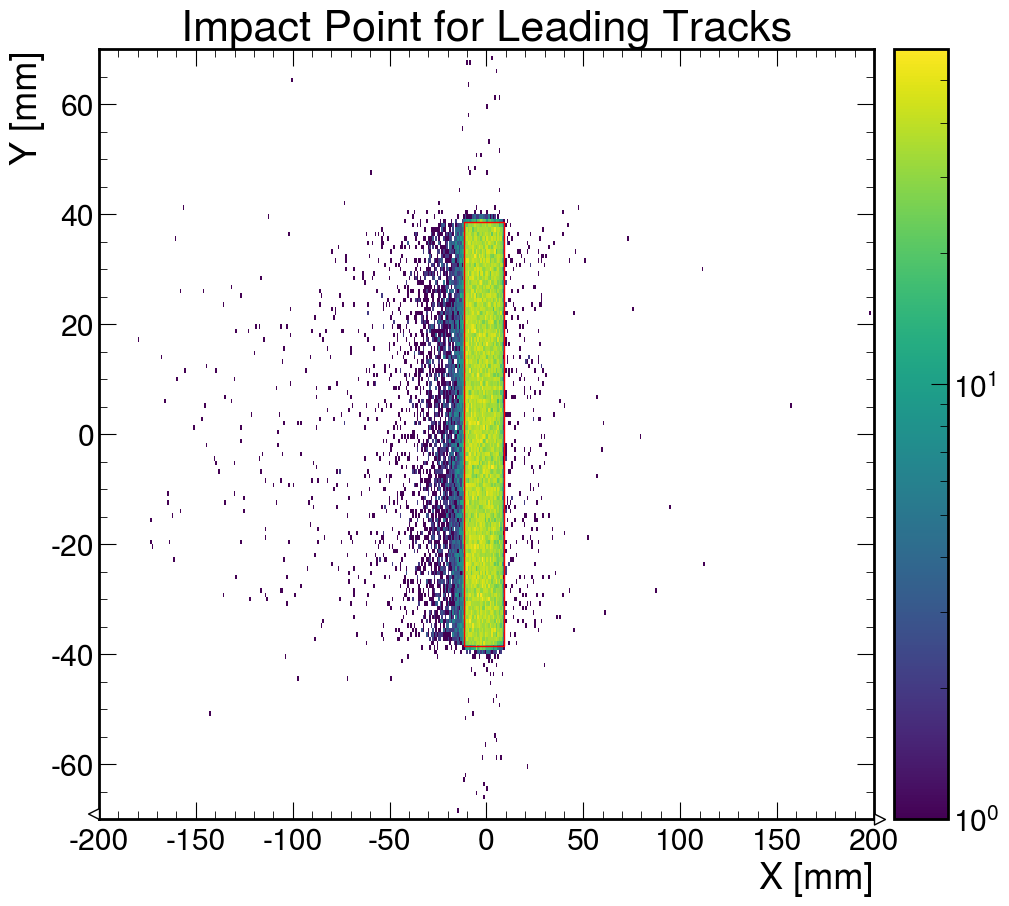

In [138]:
f['leadtrk_impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Leading Tracks")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.ylim(-70,70)
#plt.show()
#plt.savefig("leadtrk_tracks_impact_point_10M.jpg")

(-70.0, 70.0)

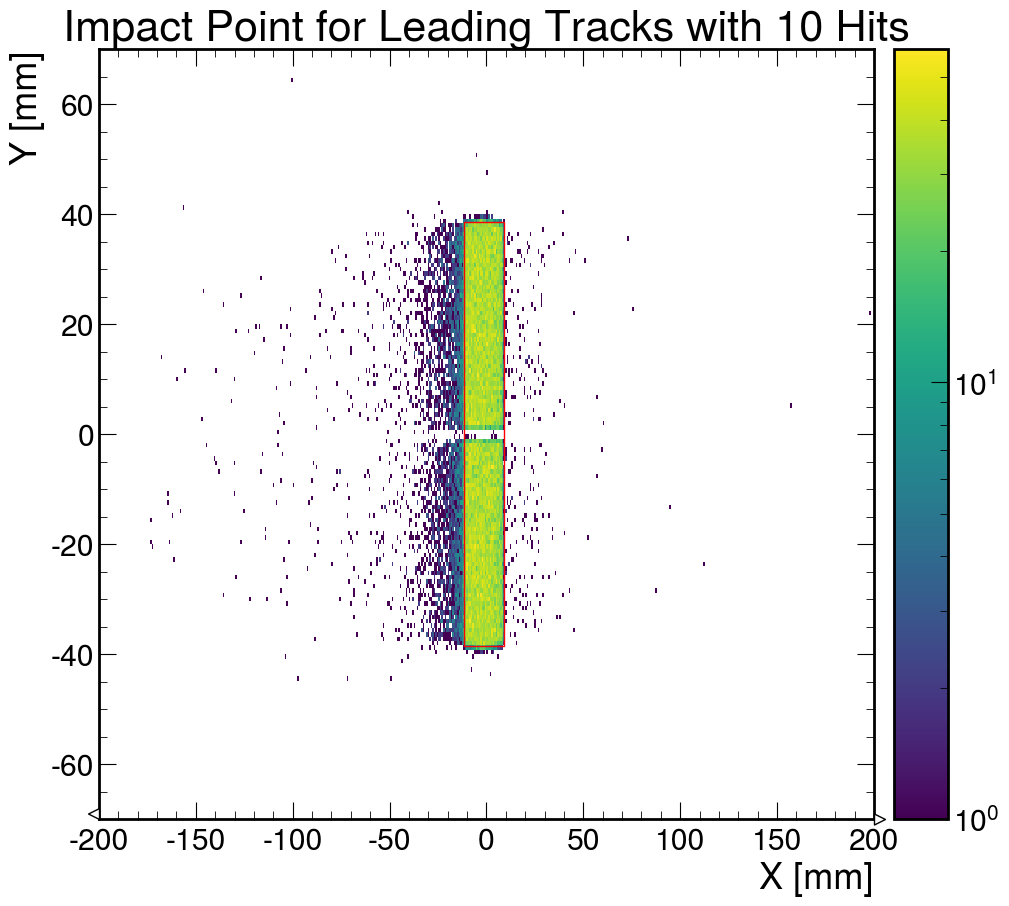

In [139]:
f['leadtrk_nhits_10_impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Leading Tracks with 10 Hits")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.ylim(-70,70)
#plt.show()
#plt.savefig("leadtrk_tracks_impact_point_10hits_10M.jpg")

(-70.0, 70.0)

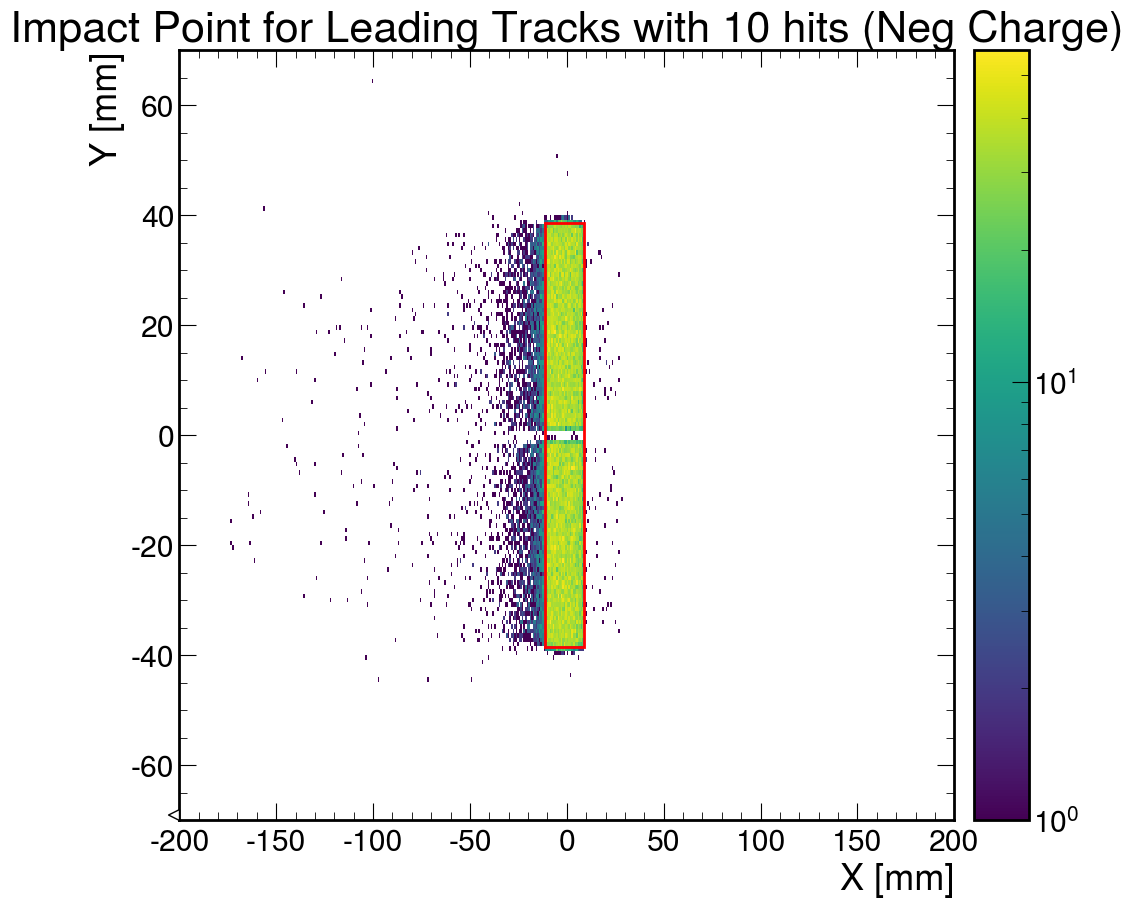

In [140]:
f['leadtrk_nhits_10_neg_charge_impact_point'].to_hist().plot(cmin=1,norm='log')
ax = plt.gca()
plt.title("Impact Point for Leading Tracks with 10 hits (Neg Charge)")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=2, edgecolor='r', facecolor='none')
blect = patches.Rectangle((-20, -50), 40, 100, linewidth=1, edgecolor='black', facecolor='none')
ax.add_patch(rect)
plt.ylim(-70,70)
#ax.add_patch(blect)
#plt.show()
#plt.savefig("leadtrk_tracks_impact_point_10hits_neg_charge_10M.jpg")

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd099c35dc0>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd09b200c80>, text=[])

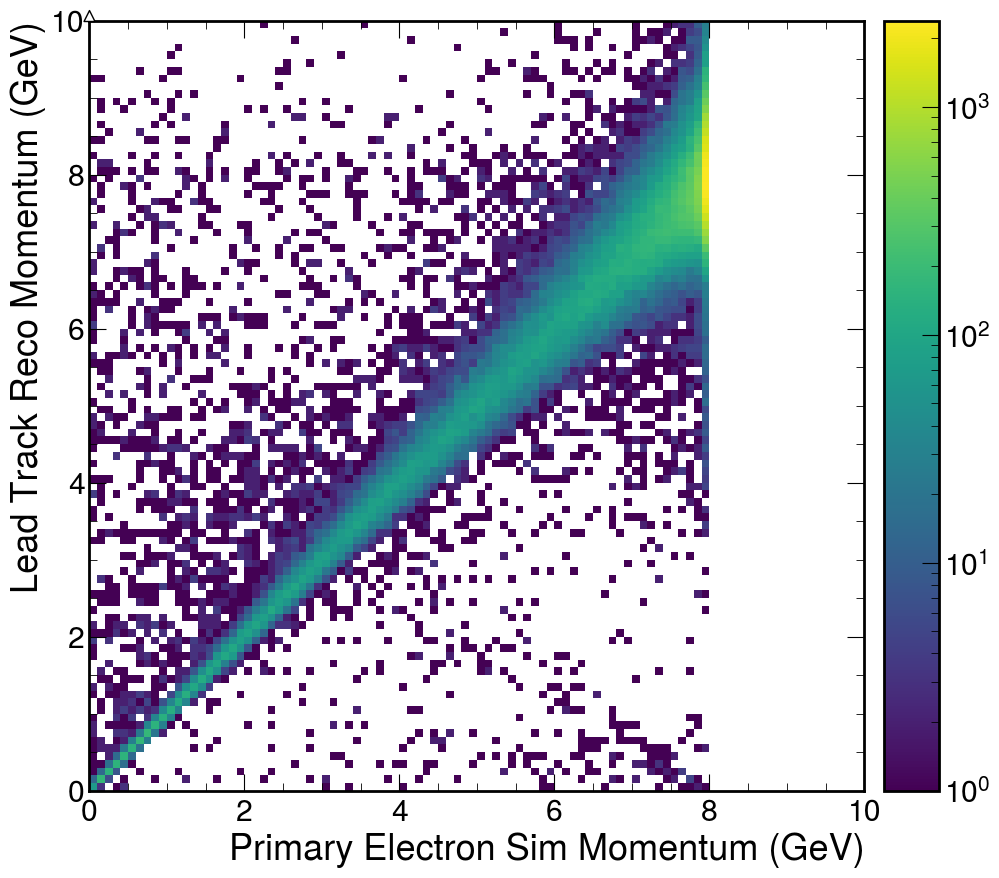

In [141]:
h=f['leadtrk_reco_vs_sim_momentum'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
#plt.title("Lead Track")
h.plot(cmin=1, norm='log')
#plt.axhline(8)
#plt.axhline(3)
#plt.axline((0, 0), slope=1,color="red", linestyle="--", label="y = x")
#.axline((8, 0), slope=-1,color="black", linestyle="--")
#plt.show()
#plt.savefig("leadtrk_reco_vs_sim_momentum_10M.jpg")

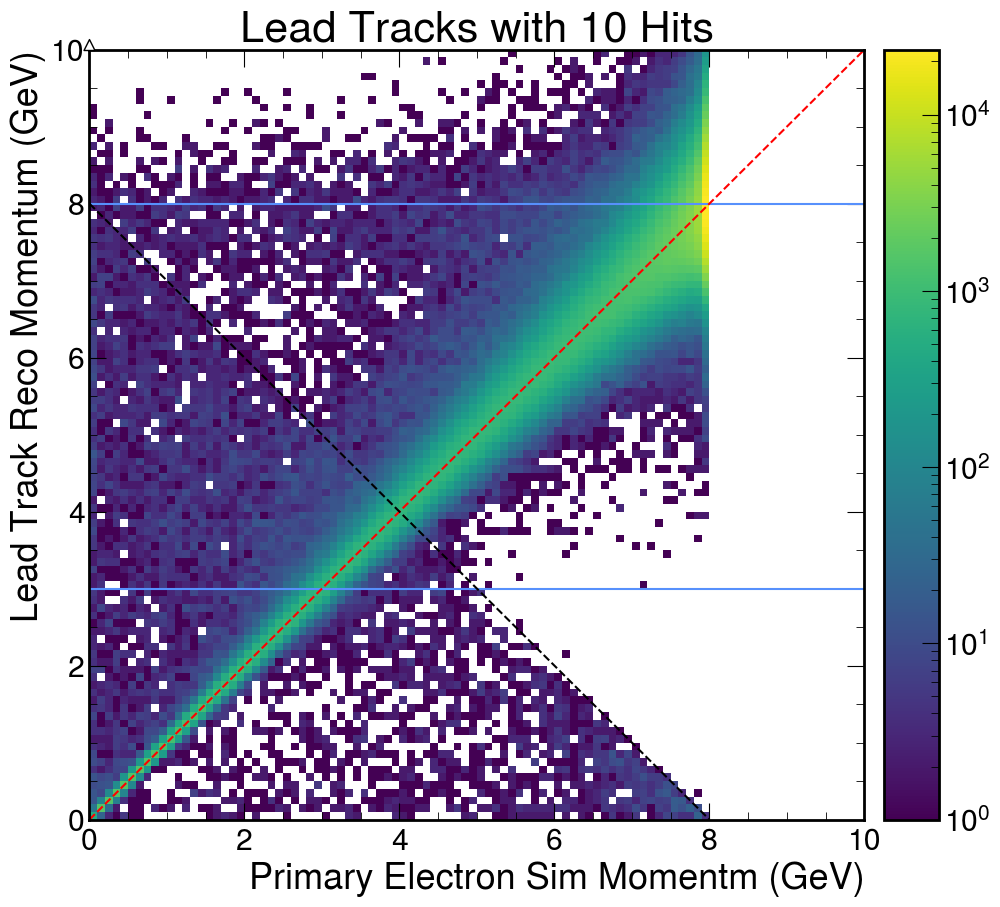

In [119]:
h=f['leadtrk_reco_vs_sim_momentum_nhits_10'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
plt.title("Lead Tracks with 10 Hits")
h.plot(cmin=1, norm='log')
plt.axhline(8)
plt.axhline(3)
plt.axline((0, 0), slope=1,color="red", linestyle="--", label="y = x")
plt.axline((8, 0), slope=-1,color="black", linestyle="--")
#plt.show()
#plt.savefig("leadtrk_reco_vs_sim_momentum_10_hits_10M-demarcation.jpg")

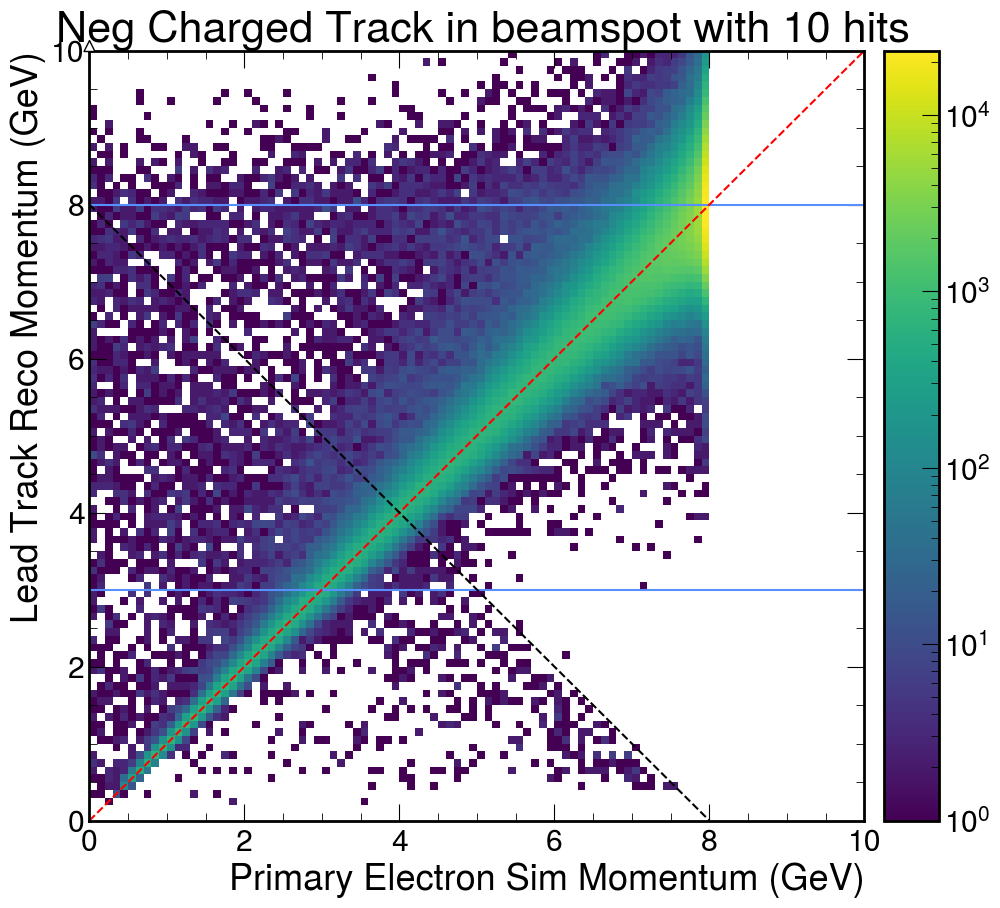

In [120]:
h=f['leadtrk_reco_vs_sim_momentum_all_reqs'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
plt.title(" Neg Charged Track in beamspot with 10 hits")
h.plot(cmin=1, norm='log')
plt.axhline(8)
plt.axhline(3)
plt.axline((0, 0), slope=1,color="red", linestyle="--", label="y = x")
plt.axline((8, 0), slope=-1,color="black", linestyle="--")
#plt.show()
#plt.savefig("leadtrk_reco_vs_sim_momentum_10M_all_reqs-demarcation.jpg")

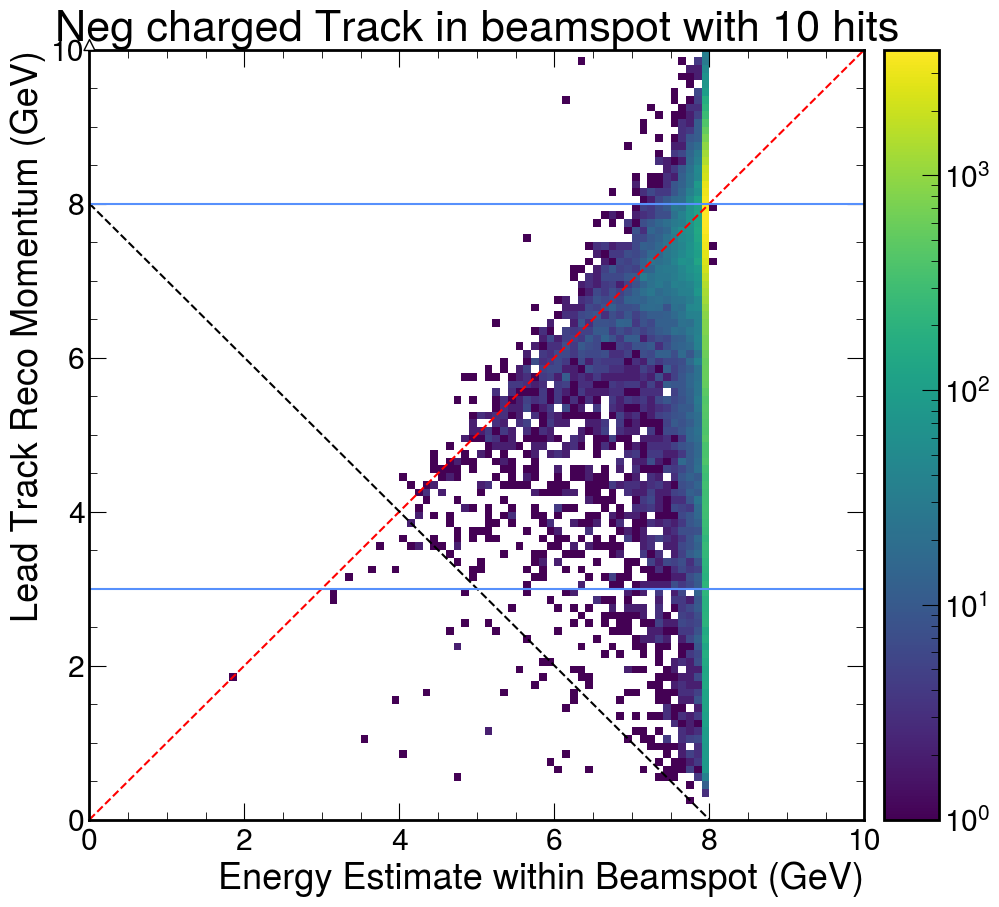

In [142]:
h=f['leadtrk_reco_all_reqs_vs_Energy_Estimate_Beamspot'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
plt.title("Neg charged Track in beamspot with 10 hits")
h.plot(cmin=1, norm="log")
plt.axline((0, 0), slope=1,color="red", linestyle="--")
plt.axline((8, 0), slope=-1,color="black", linestyle="--")
plt.axhline(8)
plt.axhline(3)
#plt.show()
#plt.savefig("leadtrk_reco_all_reqs_vs_energy_estimate_beamspot_demarcation.jpg")

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fd0998b6750>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fd0997a2780>, text=[])

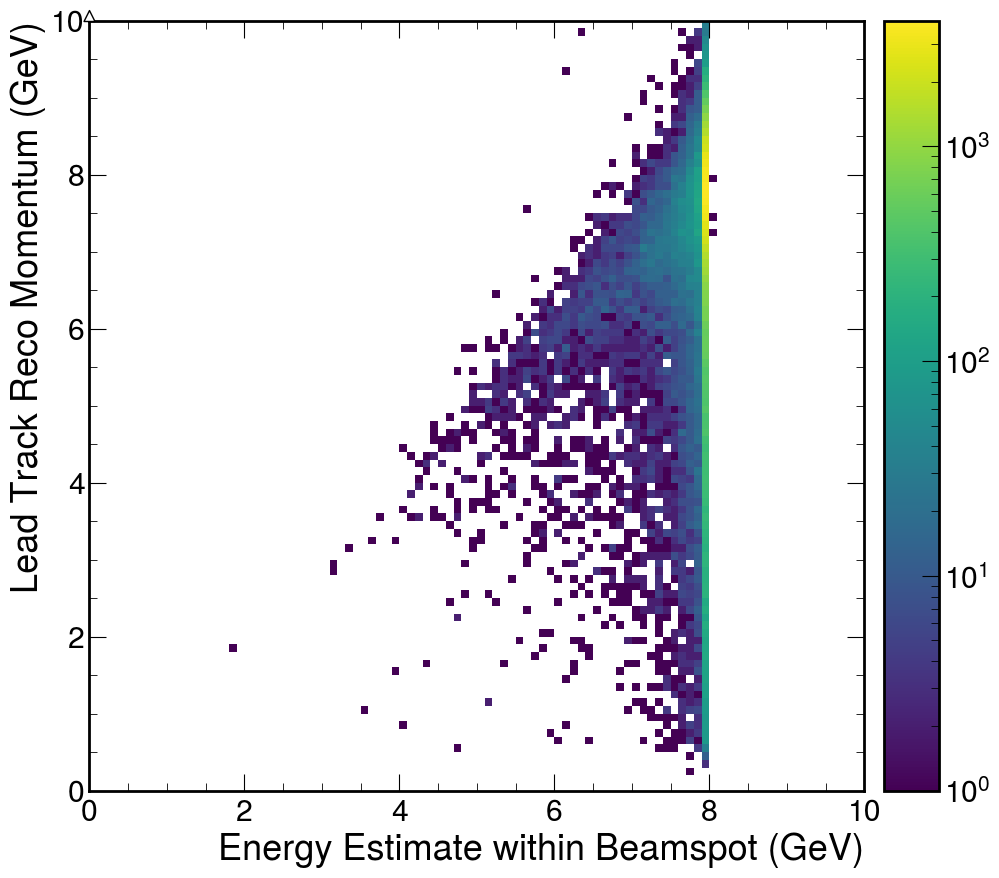

In [143]:
h=f['leadtrk_reco_all_reqs_vs_Energy_Estimate_Beamspot'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
#plt.title("Lead Track")
h.plot(cmin=1, norm="log")
#plt.axline((0, 0), slope=1,color="red", linestyle="--")
#plt.axline((8, 0), slope=-1,color="black", linestyle="--")
#plt.show()
#plt.savefig("leadtrk_reco_all_reqs_vs_energy_estimate_beamspot_10M.jpg")

In [ ]:
h=f['leadtrk_reco_nhits_10_impact_cuts_vs_Energy_Estimate_R2'].to_hist()
#h_rebin = h[{0:hist.rebin(),1:hist.rebin(5)}]
plt.title("Lead Track within Impact Region")
h.plot(cmin=1, norm='log')
#plt.show()
#plt.savefig("all_reqs_leadtrk_reco_vs_energy_estimate_R2-10M.jpg")

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fad7fbc8d10>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

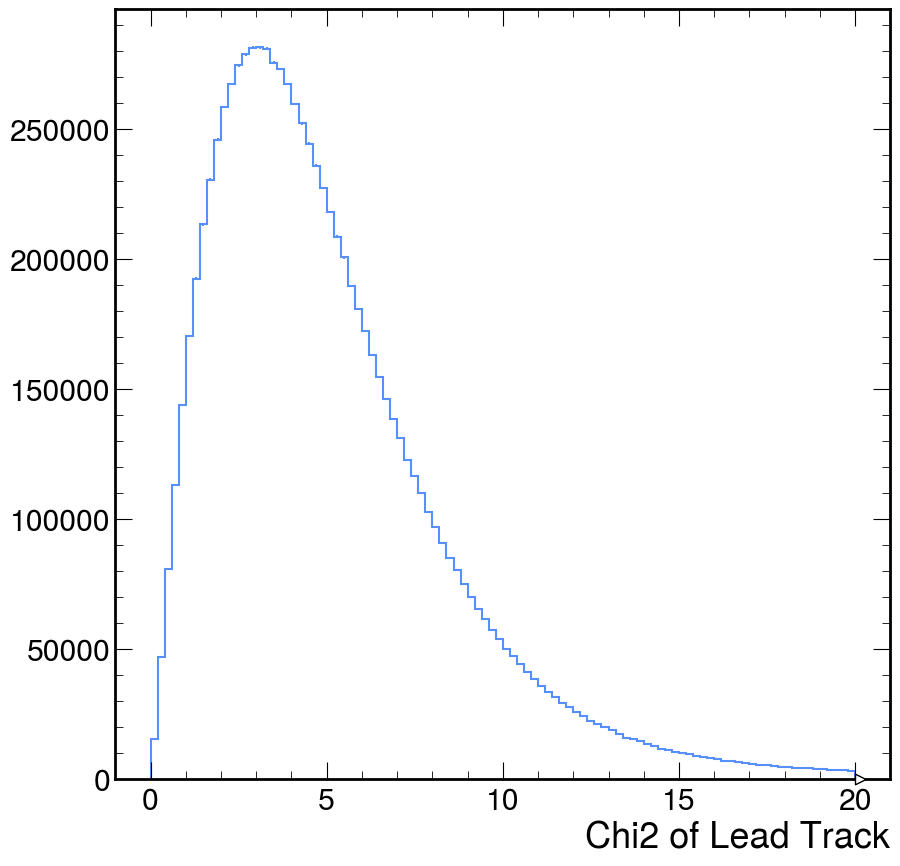

In [23]:
f['leadtrk_chi2'].to_hist().plot()
#plt.yscale("log")
#plt.savefig("leadtrk_chi2_zoom.jpg")

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fad714245c0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

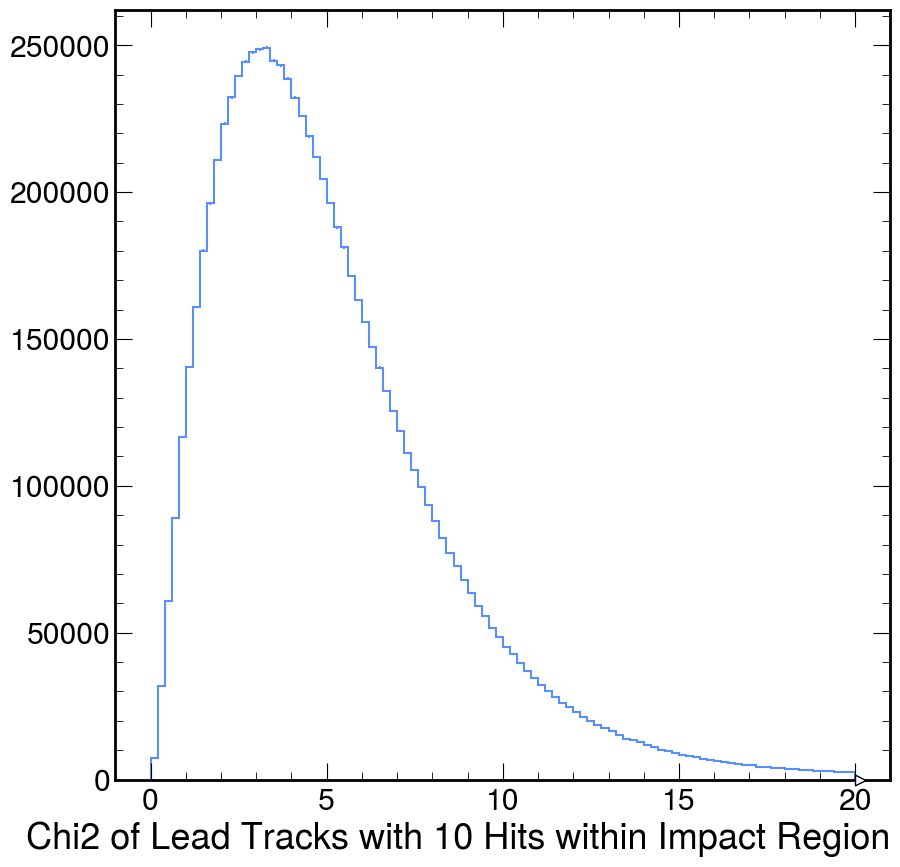

In [24]:
f['leadtrk_chi2_nhits_10_impact_cuts'].to_hist().plot()

#plt.savefig("leadtrk_chi2_nhits_10_impact_cuts_zoom.jpg")

Text(0.5, 1.0, 'Leading Tracks with Impact Point Cuts')

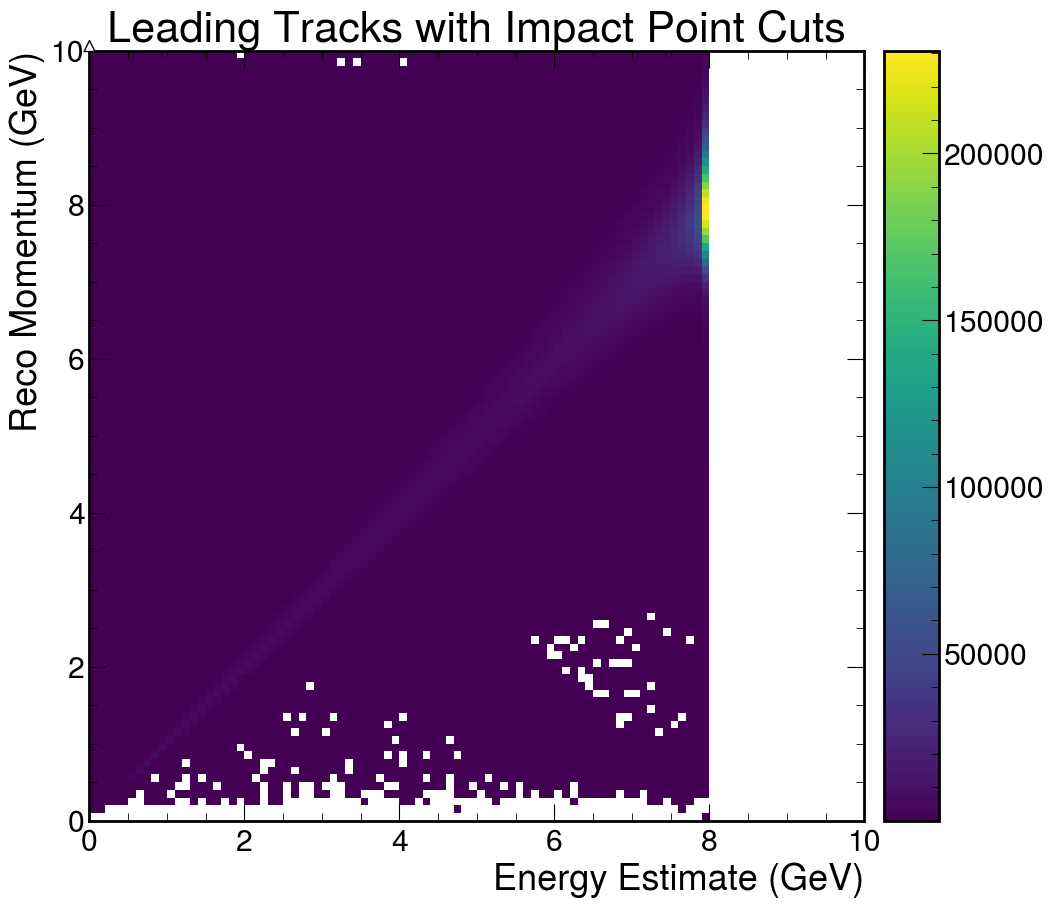

In [77]:
f['leadtrk_reco_vs_sim_momentum_impact_cuts'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with Impact Point Cuts")

#plt.savefig("leadtrk_reco_vs_sim_momentum_impact_cuts.jpg")

Text(0.5, 1.0, 'Leading Tracks with 10 Hits - Impact Point Cuts')

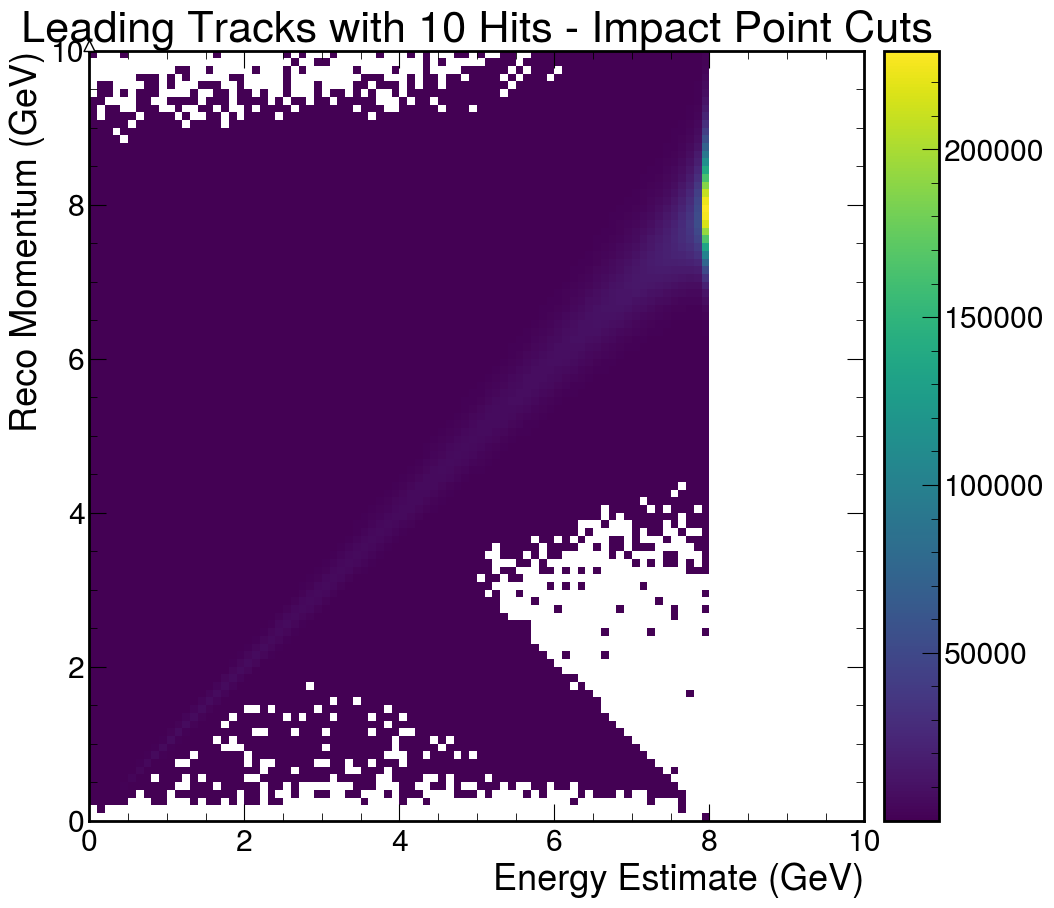

In [76]:
f['leadtrk_reco_vs_sim_momentum_nhits_10_impact_cuts'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with 10 Hits - Impact Point Cuts")

#plt.savefig("leadtrk_reco_vs_sim_momentum_nhits_10_impact_cuts.jpg")